In [1]:
#  !pip install matplotlib

In [2]:
# import library standart
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

# Scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve,
    precision_score, recall_score,
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# Global plot
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "figure.dpi":        120,
})

# Color palette 
PAL = {
    "fraud": "#DC2626", 
    "legit": "#16A34A",  
    "blue":  "#2563EB",
    "amber": "#D97706",
    "navy":  "#1B3A6B",
    "gray":  "#6B7280",
}

# Reproducibility seed 
SEED = 42

print(" Setup complete.")

 Setup complete.


In [3]:
# Standard imports
import pandas as pd
import numpy as np

#  Configuration 
DATA_PATH = r"fraud.csv"  

# Columns that contain quote 
QUOTED_COLS = ["customer", "age", "gender", "zipcodeOri",
               "merchant", "zipMerchant", "category"]

#  Load 
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

Raw shape  : 594,643 rows × 10 columns


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0


In [4]:
#  Strip quote artifacts 

df = df_raw.copy()
for col in QUOTED_COLS:
    df[col] = df[col].astype(str).str.strip("'")

print("Unique values after stripping (sanity check):")
for col in ["age", "gender", "category"]:
    print(f"  {col}: {sorted(df[col].unique())}")

Unique values after stripping (sanity check):
  age: ['0', '1', '2', '3', '4', '5', '6', 'U']
  gender: ['E', 'F', 'M', 'U']
  category: ['es_barsandrestaurants', 'es_contents', 'es_fashion', 'es_food', 'es_health', 'es_home', 'es_hotelservices', 'es_hyper', 'es_leisure', 'es_otherservices', 'es_sportsandtoys', 'es_tech', 'es_transportation', 'es_travel', 'es_wellnessandbeauty']


In [5]:
# Data quality report 
print("=" * 55)
print("DATA QUALITY REPORT")
print("=" * 55)
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

nulls = df.isnull().sum()
print(f"Missing values : {'None ' if nulls.sum() == 0 else nulls[nulls > 0]}")

vc = df["fraud"].value_counts()
fraud_rate = df["fraud"].mean() * 100
print(f"\nClass balance:")
print(f"  Legitimate : {vc[0]:,}  ({100-fraud_rate:.2f}%)")
print(f"  Fraud      : {vc[1]:,}  ({fraud_rate:.2f}%)")
print(f"  Ratio      : {vc[0]/vc[1]:.0f}:1 (legitimate:fraud)")
print("=" * 55)

DATA QUALITY REPORT
Shape          : 594,643 rows × 10 columns
Memory usage   : 247.5 MB
Missing values : None 

Class balance:
  Legitimate : 587,443  (98.79%)
  Fraud      : 7,200  (1.21%)
  Ratio      : 82:1 (legitimate:fraud)


In [6]:
# Dtypes overview 
df.dtypes.to_frame("dtype")

,dtype
step,int64
customer,str
age,str
gender,str
zipcodeOri,str
merchant,str
zipMerchant,str
category,str
amount,float64
fraud,int64


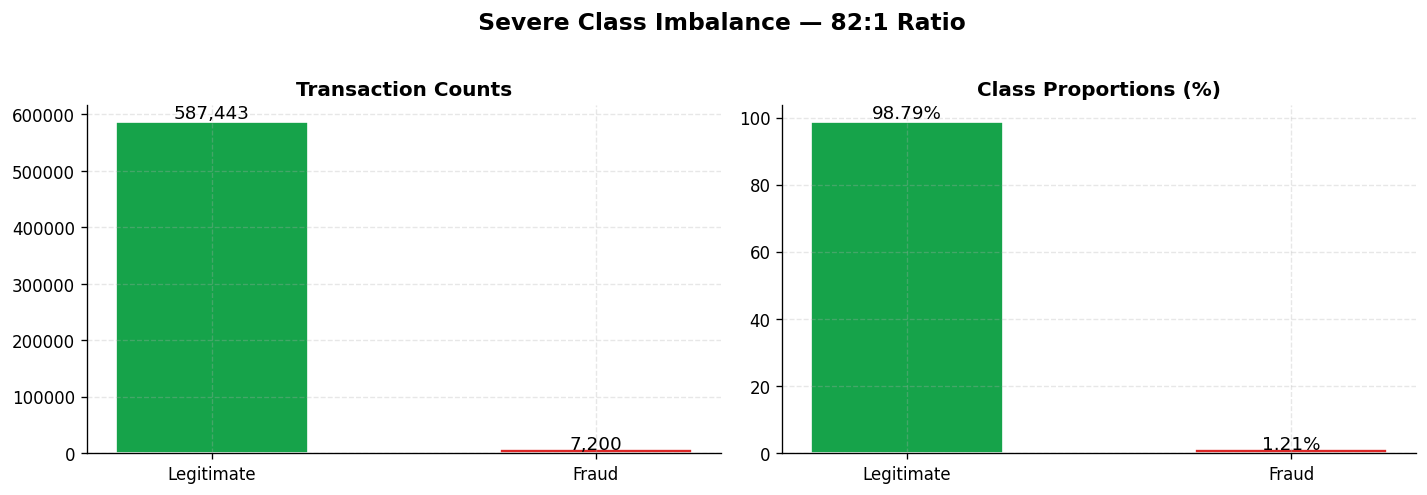

  Naïve all-benign accuracy: 98.79% — this is NOT a good model!


In [7]:
# Class distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ["Legitimate", "Fraud"]
colors = [PAL["legit"], PAL["fraud"]]

# Count bars
axes[0].bar(labels, [vc[0], vc[1]], color=colors, width=0.5, edgecolor="white")
axes[0].set_title("Transaction Counts", fontweight="bold")
for i, v in enumerate([vc[0], vc[1]]):
    axes[0].text(i, v * 1.01, f"{v:,}", ha="center", fontsize=11)

# Percentage bars
pcts = [vc[0] / len(df) * 100, vc[1] / len(df) * 100]
axes[1].bar(labels, pcts, color=colors, width=0.5, edgecolor="white")
axes[1].set_title("Class Proportions (%)", fontweight="bold")
for i, v in enumerate(pcts):
    axes[1].text(i, v * 1.01, f"{v:.2f}%", ha="center", fontsize=11)

fig.suptitle("  Severe Class Imbalance — 82:1 Ratio", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"  Naïve all-benign accuracy: {100 - fraud_rate:.2f}% — this is NOT a good model!")

Amount statistics by class:
fraud          0        1
count  587443.00  7200.00
mean       31.85   530.93
std        31.47   835.59
min         0.00     0.03
25%        13.59   159.98
50%        26.61   319.18
75%        41.90   548.98
max      2144.86  8329.96

 Fraud mean: $530.93  |  Legit mean: $31.85
   Fraud amounts are 16.7× HIGHER than legitimate


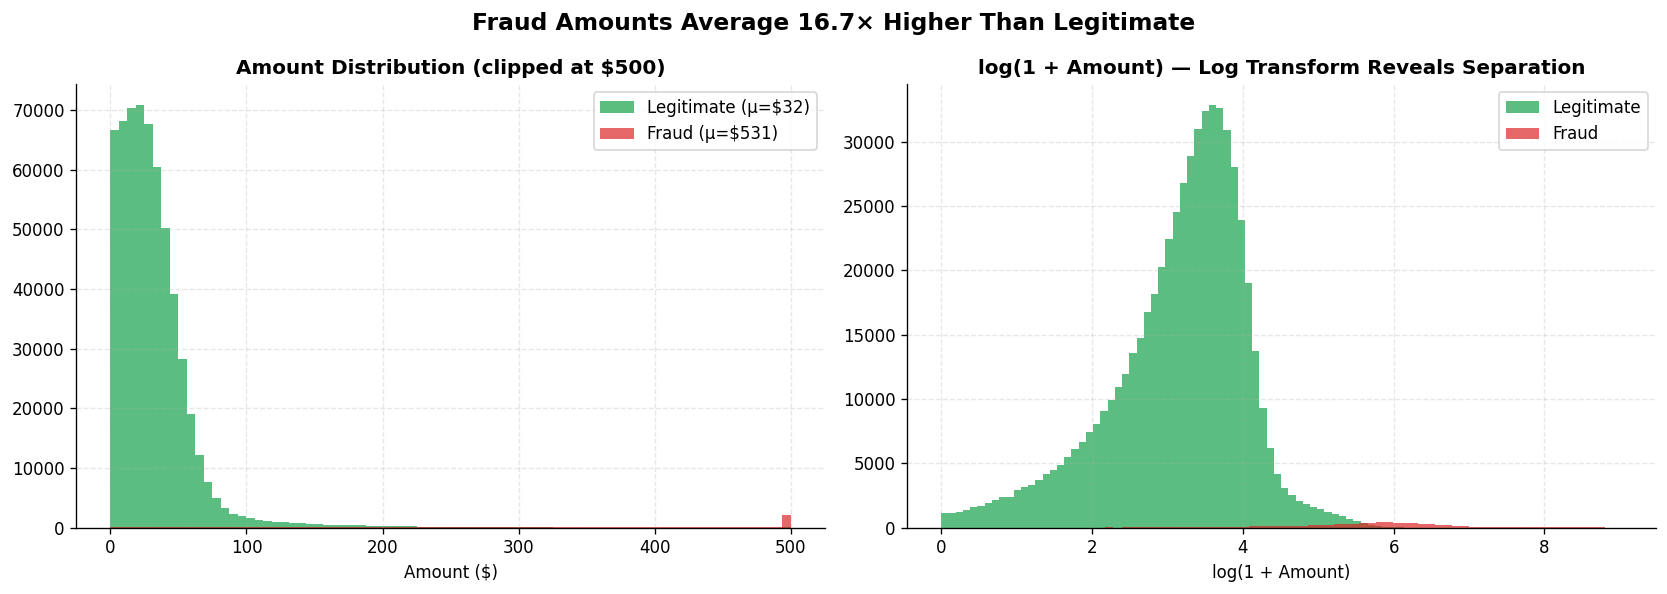

In [8]:
# Transaction amount distribution 

fraud_amt = df[df["fraud"] == 1]["amount"]
legit_amt = df[df["fraud"] == 0]["amount"]

print("Amount statistics by class:")
print(df.groupby("fraud")["amount"].describe().round(2).T)
print(f"\n Fraud mean: ${fraud_amt.mean():,.2f}  |  Legit mean: ${legit_amt.mean():,.2f}")
print(f"   Fraud amounts are {fraud_amt.mean() / legit_amt.mean():.1f}× HIGHER than legitimate")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(legit_amt.clip(upper=500), bins=80, alpha=0.7,
             color=PAL["legit"], label=f"Legitimate (μ=${legit_amt.mean():.0f})")
axes[0].hist(fraud_amt.clip(upper=500), bins=80, alpha=0.7,
             color=PAL["fraud"], label=f"Fraud (μ=${fraud_amt.mean():.0f})")
axes[0].set_title("Amount Distribution (clipped at $500)", fontweight="bold")
axes[0].set_xlabel("Amount ($)")
axes[0].legend()

axes[1].hist(np.log1p(legit_amt), bins=80, alpha=0.7, color=PAL["legit"], label="Legitimate")
axes[1].hist(np.log1p(fraud_amt), bins=80, alpha=0.7, color=PAL["fraud"], label="Fraud")
axes[1].set_title("log(1 + Amount) — Log Transform Reveals Separation", fontweight="bold")
axes[1].set_xlabel("log(1 + Amount)")
axes[1].legend()

fig.suptitle("Fraud Amounts Average 16.7× Higher Than Legitimate",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Fraud rate by category (sorted high → low):
                        count  fraud_n  fraud_pct
category                                         
es_leisure                499      474      94.99
es_travel                 728      578      79.40
es_sportsandtoys         4002     1982      49.53
es_hotelservices         1744      548      31.42
es_otherservices          912      228      25.00
es_home                  1986      302      15.21
es_health               16133     1696      10.51
es_tech                  2370      158       6.67
es_wellnessandbeauty    15086      718       4.76
es_hyper                 6098      280       4.59
es_barsandrestaurants    6373      120       1.88
es_fashion               6454      116       1.80
es_contents               885        0       0.00
es_food                 26254        0       0.00
es_transportation      505119        0       0.00


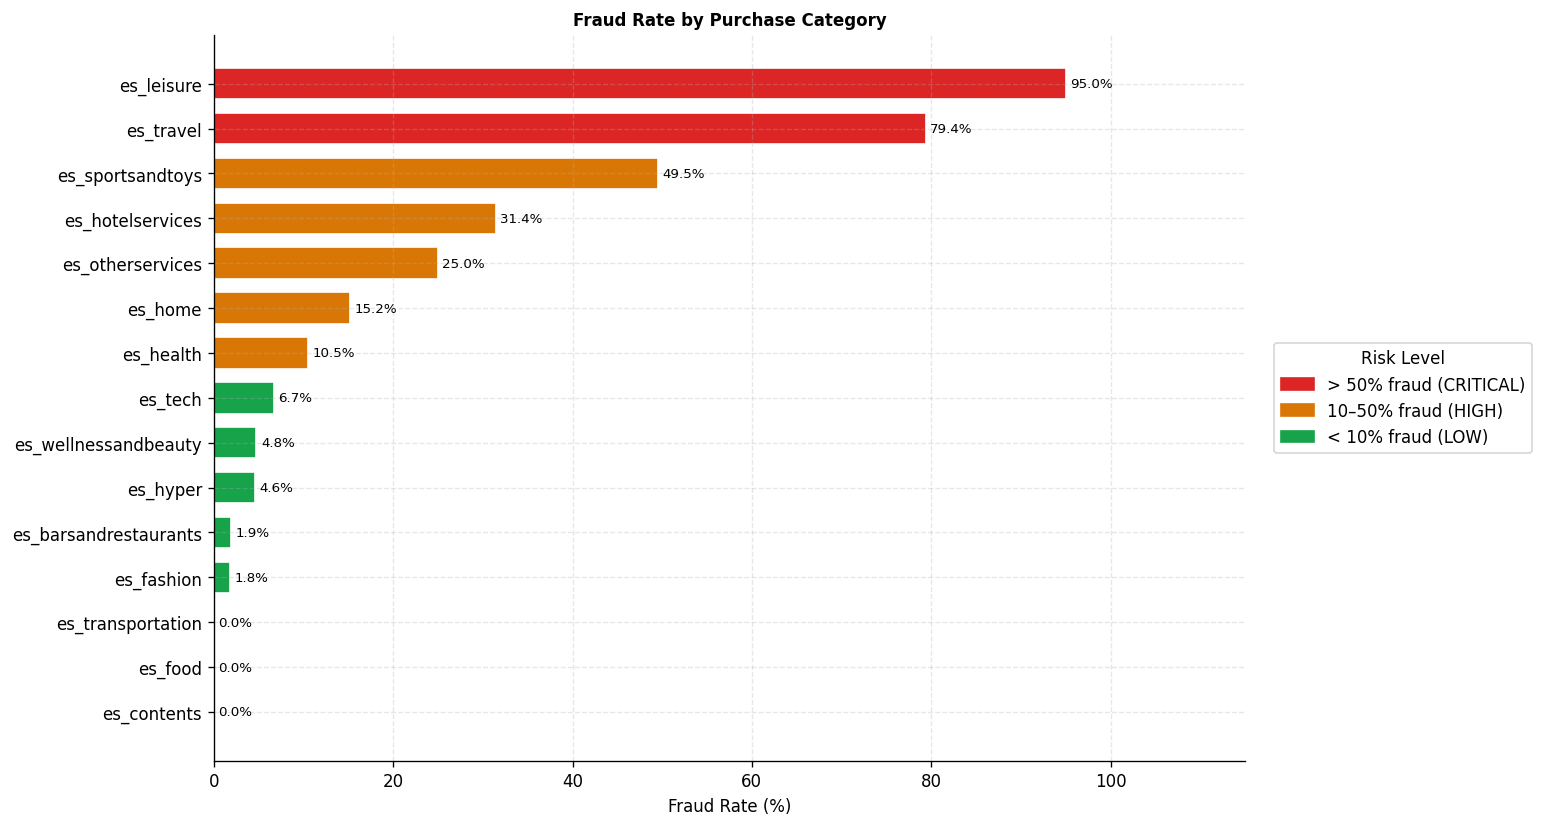

In [9]:
# 2 Category fraud rates

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

cat_stats = df.groupby("category").agg(
    count=("fraud", "count"),
    fraud_n=("fraud", "sum"),
    fraud_rate=("fraud", "mean"),
).sort_values("fraud_rate", ascending=False)

cat_stats["fraud_pct"] = (cat_stats["fraud_rate"] * 100).round(2)

print("Fraud rate by category (sorted high → low):")
print(cat_stats[["count", "fraud_n", "fraud_pct"]].to_string())

# Horizontal bar chart
cat_plot = cat_stats.sort_values("fraud_rate", ascending=True)

bar_colors = [
    PAL["fraud"] if r > 0.50 else
    PAL["amber"] if r > 0.10 else
    PAL["legit"]
    for r in cat_plot["fraud_rate"]
]

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    cat_plot.index,
    cat_plot["fraud_rate"] * 100,
    color=bar_colors,
    edgecolor="white",
    height=0.7
)

# Add percentage labels
for bar, (_, row) in zip(bars, cat_plot.iterrows()):
    pct = row["fraud_rate"] * 100
    ax.text(
        pct + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center",
        fontsize=8
    )

ax.set_xlabel("Fraud Rate (%)")
ax.set_title(
    "Fraud Rate by Purchase Category",
    fontsize=10,
    fontweight="bold"
)
ax.set_xlim(0, 115)

# Legend
legend = [
    mpatches.Patch(color=PAL["fraud"], label="> 50% fraud (CRITICAL)"),
    mpatches.Patch(color=PAL["amber"], label="10–50% fraud (HIGH)"),
    mpatches.Patch(color=PAL["legit"], label="< 10% fraud (LOW)")
]

# Move legend to the right side
ax.legend(
    handles=legend,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Risk Level"
)

plt.tight_layout()
plt.show()

Step range: 0 → 179  (7.5 days)

Top 5 highest-fraud hours:
hour_of_day
0     1.234949
1     1.233854
2     1.225819
3     1.221141
13    1.219512


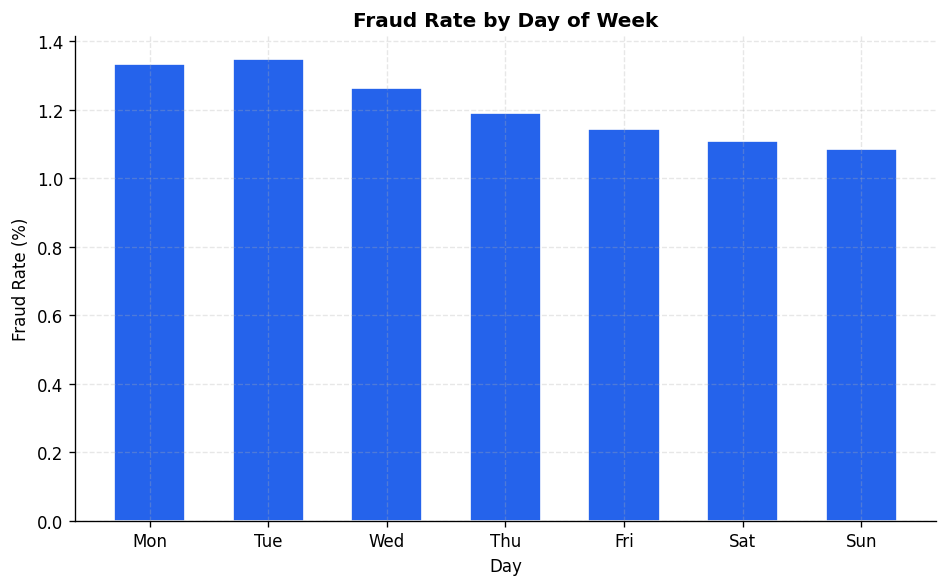

In [10]:
# Temporal patterns

df["hour_of_day"] = df["step"] % 24
df["day_of_week"] = (df["step"] // 24) % 7

hourly = df.groupby("hour_of_day")["fraud"].mean() * 100
daily = df.groupby("day_of_week")["fraud"].mean() * 100

print(f"Step range: {df['step'].min()} → {df['step'].max()}  ({(df['step'].max()+1)/24:.1f} days)")

print("\nTop 5 highest-fraud hours:")
print(hourly.sort_values(ascending=False).head(5).to_string())

# Only Day-of-Week plot
fig, ax = plt.subplots(figsize=(8, 5))

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

ax.bar(
    day_labels[:len(daily)],
    daily.values,
    color=PAL["blue"],
    edgecolor="white",
    width=0.6
)

ax.set_title("Fraud Rate by Day of Week", fontweight="bold")
ax.set_xlabel("Day")
ax.set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

In [11]:
# Demographic breakdown 

print("Fraud rate by GENDER:")
g = df.groupby("gender")["fraud"].agg(count="count", fraud_n="sum", fraud_rate="mean")
g["fraud_pct"] = (g["fraud_rate"] * 100).round(2)
print(g[["count", "fraud_n", "fraud_pct"]].sort_values("fraud_pct", ascending=False))

age_map = {"0":"≤18","1":"19-25","2":"26-35","3":"36-45","4":"46-55","5":"56-65","6":">65","U":"Unknown"}
df["age_label"] = df["age"].map(age_map)

print("\nFraud rate by AGE GROUP:")
a = df.groupby("age_label")["fraud"].agg(count="count", fraud_n="sum", fraud_rate="mean")
a["fraud_pct"] = (a["fraud_rate"] * 100).round(2)
print(a[["count", "fraud_n", "fraud_pct"]].sort_values("fraud_pct", ascending=False))



Fraud rate by GENDER:
         count  fraud_n  fraud_pct
gender                            
F       324565     4758       1.47
M       268385     2435       0.91
E         1178        7       0.59
U          515        0       0.00

Fraud rate by AGE GROUP:
            count  fraud_n  fraud_pct
age_label                            
≤18          2452       48       1.96
46-55      109025     1410       1.29
26-35      187310     2344       1.25
19-25       58131      689       1.19
36-45      147131     1755       1.19
56-65       62642      686       1.10
>65         26774      261       0.97
Unknown      1178        7       0.59


In [12]:
# Zero-variance feature detection 

print("Unique value counts:")
for col in ["zipcodeOri", "zipMerchant"]:
    n = df[col].nunique()
    decision = " DROP (zero variance)" if n == 1 else "✓ KEEP"
    print(f"  {col:<15s}: {n} unique value(s)  → {decision}")
    if n == 1:
        print(f"    Value: {df[col].iloc[0]}")

Unique value counts:
  zipcodeOri     : 1 unique value(s)  →  DROP (zero variance)
    Value: 28007
  zipMerchant    : 1 unique value(s)  →  DROP (zero variance)
    Value: 28007


In [13]:
# Merchant & customer cardinality 

print(f"Unique merchants : {df['merchant'].nunique()}")
print(f"Unique customers : {df['customer'].nunique()}")

merch_fraud = df.groupby("merchant")["fraud"].mean().sort_values(ascending=False)
print("\nTop 5 merchants by fraud rate:")
print(merch_fraud.head(5).apply(lambda x: f"{x*100:.1f}%"))
print("\nBottom 5 merchants by fraud rate:")
print(merch_fraud.tail(5).apply(lambda x: f"{x*100:.1f}%"))

# The merchant fraud rate turned out to be the most important feature in the model, contributing approximately 29.5% of the total feature importance.

Unique merchants : 50
Unique customers : 4112

Top 5 merchants by fraud rate:
merchant
M1294758098    96.3%
M3697346       94.2%
M1873032707    86.4%
M732195782     85.2%
M980657600     83.2%
Name: fraud, dtype: str

Bottom 5 merchants by fraud rate:
merchant
M117188757     0.0%
M45060432      0.0%
M1352454843    0.0%
M349281107     0.0%
M1053599405    0.0%
Name: fraud, dtype: str


In [14]:
# Label encoding 

CATEGORICAL_COLS = ["age", "gender", "category"]
encoders = {}

df_proc = df.copy()

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_proc[f"{col}_enc"] = le.fit_transform(df_proc[col])
    encoders[col] = le

    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col} encoding: {mapping}")

print(f"\nColumns added: {[c+'_enc' for c in CATEGORICAL_COLS]}")

age encoding: {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3': np.int64(3), '4': np.int64(4), '5': np.int64(5), '6': np.int64(6), 'U': np.int64(7)}
gender encoding: {'E': np.int64(0), 'F': np.int64(1), 'M': np.int64(2), 'U': np.int64(3)}
category encoding: {'es_barsandrestaurants': np.int64(0), 'es_contents': np.int64(1), 'es_fashion': np.int64(2), 'es_food': np.int64(3), 'es_health': np.int64(4), 'es_home': np.int64(5), 'es_hotelservices': np.int64(6), 'es_hyper': np.int64(7), 'es_leisure': np.int64(8), 'es_otherservices': np.int64(9), 'es_sportsandtoys': np.int64(10), 'es_tech': np.int64(11), 'es_transportation': np.int64(12), 'es_travel': np.int64(13), 'es_wellnessandbeauty': np.int64(14)}

Columns added: ['age_enc', 'gender_enc', 'category_enc']


In [15]:
# Drop zero-variance columns 

ZERO_VAR_COLS = ["zipcodeOri", "zipMerchant"]
df_proc = df_proc.drop(columns=ZERO_VAR_COLS)

print(f"Dropped: {ZERO_VAR_COLS}")
print(f"DataFrame shape after preprocessing: {df_proc.shape}")
print(f"Columns: {list(df_proc.columns)}")

Dropped: ['zipcodeOri', 'zipMerchant']
DataFrame shape after preprocessing: (594643, 14)
Columns: ['step', 'customer', 'age', 'gender', 'merchant', 'category', 'amount', 'fraud', 'hour_of_day', 'day_of_week', 'age_label', 'age_enc', 'gender_enc', 'category_enc']


In [16]:
# Temporal features 
# hour of day  : 0–23
# day of week  : 0 (Mon) – 6 (Sun)
# is_night     : 1 if hour ∈ [22, 23, 0, 1, 2, 3, 4, 5]

df_proc["hour_of_day"] = df_proc["step"] % 24
df_proc["day_of_week"] = (df_proc["step"] // 24) % 7
df_proc["is_night"]    = ((df_proc["hour_of_day"] < 6) |
                          (df_proc["hour_of_day"] >= 22)).astype(int)

night_fraud_rate = df_proc[df_proc["is_night"] == 1]["fraud"].mean() * 100
day_fraud_rate   = df_proc[df_proc["is_night"] == 0]["fraud"].mean() * 100
print(f" Temporal features added")
print(f"  Night fraud rate: {night_fraud_rate:.2f}%  |  Day fraud rate: {day_fraud_rate:.2f}%")

 Temporal features added
  Night fraud rate: 1.22%  |  Day fraud rate: 1.21%


In [17]:
# Amount features 
df_proc["log_amount"] = np.log1p(df_proc["amount"])

print(f" log_amount added")
print(f"  amount     — skewness: {df_proc['amount'].skew():.2f}")
print(f"  log_amount — skewness: {df_proc['log_amount'].skew():.2f}  (muchmore symmetric-Bell Shappped-Eaiser for the model tolearn)")

 log_amount added
  amount     — skewness: 32.37
  log_amount — skewness: -0.42  (muchmore symmetric-Bell Shappped-Eaiser for the model tolearn)


In [18]:
# Final feature list 

ALL_FEATURES = [
    # Raw
    "step",
    # Encoded categoricals
    "age_enc", "gender_enc", "category_enc",
    # Temporal
    "hour_of_day", "day_of_week", "is_night",
    # Amount
    "amount", "log_amount",
    # Customer
    "cust_tx_count", "cust_avg_amount", "cust_max_amount",
    # Merchant
    "merch_fraud_rate", "merch_tx_count",
    # Category
    "cat_fraud_rate",
]

print(f"Total features: {len(ALL_FEATURES)}")
print(f"\nFeature families:")
print(f"  Raw numeric       : ['step']")
print(f"  Temporal          : {['hour_of_day','day_of_week','is_night']}")
print(f"  Amount            : {['amount','log_amount']}")
print(f"  Customer          : {['cust_tx_count','cust_avg_amount','cust_max_amount']}")
print(f"  Merchant          : {['merch_fraud_rate','merch_tx_count']}")
print(f"  Category          : {['cat_fraud_rate']}")
print(f"  Encoded cats      : {['age_enc','gender_enc','category_enc']}")


missing = [f for f in ALL_FEATURES if f not in df_proc.columns]
if missing:
    print(f"\n Missing features: {missing}")
else:
    print(f"\n All {len(ALL_FEATURES)} features present in DataFrame")

Total features: 15

Feature families:
  Raw numeric       : ['step']
  Temporal          : ['hour_of_day', 'day_of_week', 'is_night']
  Amount            : ['amount', 'log_amount']
  Customer          : ['cust_tx_count', 'cust_avg_amount', 'cust_max_amount']
  Merchant          : ['merch_fraud_rate', 'merch_tx_count']
  Category          : ['cat_fraud_rate']
  Encoded cats      : ['age_enc', 'gender_enc', 'category_enc']

 Missing features: ['cust_tx_count', 'cust_avg_amount', 'cust_max_amount', 'merch_fraud_rate', 'merch_tx_count', 'cat_fraud_rate']


In [19]:
# Leakage-safe feature matrix extraction 
# Why this is important:
# Aggregate features such as merch_fraud_rate and cat_fraud_rate use the target
# column "fraud". If we calculate them before the train/test split, the model
# indirectly sees information from the test set.
#
# Correct order:
#   1. Split the raw rows into train/test
#   2. Calculate aggregate features from TRAIN only
#   3. Map those aggregate values to both train and test
#   4. Apply SMOTE-NC only on the training set later

BASE_FEATURES = [
    "step",
    "age_enc", "gender_enc", "category_enc",
    "hour_of_day", "day_of_week", "is_night",
    "amount", "log_amount",
]

AGG_FEATURES = [
    "cust_tx_count", "cust_avg_amount", "cust_max_amount",
    "merch_fraud_rate", "merch_tx_count",
    "cat_fraud_rate",
]

# Final feature list used by the model
ALL_FEATURES = BASE_FEATURES + AGG_FEATURES

# Split row indices first, before creating target-based aggregates
train_idx, test_idx = train_test_split(
    df_proc.index,
    test_size=0.20,
    random_state=SEED,
    stratify=df_proc["fraud"]
)

train_raw = df_proc.loc[train_idx].copy()
test_raw  = df_proc.loc[test_idx].copy()

# Global fallback values from TRAIN only 
# These are used when a customer/merchant/category appears in test but not train.
global_fraud_rate = train_raw["fraud"].mean()
global_avg_amount = train_raw["amount"].mean()
global_max_amount = train_raw["amount"].max()

# Customer aggregates from TRAIN only 
cust_stats = train_raw.groupby("customer").agg(
    cust_tx_count=("amount", "count"),
    cust_avg_amount=("amount", "mean"),
    cust_max_amount=("amount", "max"),
)

# Merchant aggregates from TRAIN only 
merch_stats = train_raw.groupby("merchant").agg(
    merch_fraud_rate=("fraud", "mean"),
    merch_tx_count=("fraud", "count"),
)

# Category fraud rate from TRAIN only 
cat_fraud_rate = train_raw.groupby("category")["fraud"].mean()


def add_leakage_safe_aggregates(data):
    """Add aggregate features using mappings learned from the training set only."""
    data = data.copy()

    # Customer aggregates
    data = data.join(cust_stats, on="customer")
    data["cust_tx_count"]   = data["cust_tx_count"].fillna(0)
    data["cust_avg_amount"] = data["cust_avg_amount"].fillna(global_avg_amount)
    data["cust_max_amount"] = data["cust_max_amount"].fillna(global_max_amount)

    # Merchant aggregates
    data = data.join(merch_stats, on="merchant")
    data["merch_fraud_rate"] = data["merch_fraud_rate"].fillna(global_fraud_rate)
    data["merch_tx_count"]   = data["merch_tx_count"].fillna(0)

    # Category fraud rate
    data["cat_fraud_rate"] = data["category"].map(cat_fraud_rate).fillna(global_fraud_rate)

    return data


train_feat = add_leakage_safe_aggregates(train_raw)
test_feat  = add_leakage_safe_aggregates(test_raw)

X_train = train_feat[ALL_FEATURES].copy()
y_train = train_feat["fraud"].copy()

X_test = test_feat[ALL_FEATURES].copy()
y_test = test_feat["fraud"].copy()

# Full leakage-safe feature matrix for analysis only
X = pd.concat([X_train, X_test], axis=0).sort_index()
y = df_proc.loc[X.index, "fraud"]

# Add leakage-safe aggregate columns back to df_proc for manual customer testing
for col in AGG_FEATURES:
    df_proc.loc[X_train.index, col] = X_train[col]
    df_proc.loc[X_test.index, col] = X_test[col]

print(f"Feature matrix shape: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Target: {y.sum():,} fraud | {(y==0).sum():,} legitimate")
print(f"\nTrain set : {X_train.shape[0]:,} rows  |  fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test set  : {X_test.shape[0]:,} rows  |  fraud rate: {y_test.mean()*100:.2f}%")
print(f"\nTrain fraud count : {y_train.sum():,}")
print(f"Test  fraud count : {y_test.sum():,}")
print("\n Leakage-safe aggregate features created from TRAIN only.")

X.describe().round(3).T


Feature matrix shape: 594,643 rows × 15 features
Target: 7,200 fraud | 587,443 legitimate

Train set : 475,714 rows  |  fraud rate: 1.21%
Test set  : 118,929 rows  |  fraud rate: 1.21%

Train fraud count : 5,760
Test  fraud count : 1,440

 Leakage-safe aggregate features created from TRAIN only.


,count,mean,std,min,25%,50%,75%,max
step,594643.0,94.987,51.054,0.000,52.000,97.000,139.000,179.000
age_enc,594643.0,3.014,1.336,0.000,2.000,3.000,4.000,7.000
gender_enc,594643.0,1.451,0.503,0.000,1.000,1.000,2.000,3.000
category_enc,594643.0,11.066,2.817,0.000,12.000,12.000,12.000,14.000
hour_of_day,594643.0,11.154,6.911,0.000,5.000,11.000,17.000,23.000
day_of_week,594643.0,2.966,2.074,0.000,1.000,3.000,5.000,6.000
is_night,594643.0,0.343,0.475,0.000,0.000,0.000,1.000,1.000
amount,594643.0,37.890,111.403,0.000,13.740,26.900,42.540,8329.960
log_amount,594643.0,3.176,0.955,0.000,2.691,3.329,3.774,9.028
cust_tx_count,594643.0,125.815,23.376,3.000,121.000,133.000,140.000,213.000


In [20]:
# Correlation with fraud target 

correlations = X.apply(lambda col: col.corr(y)).sort_values(key=abs, ascending=False)

print("Point-biserial correlations with fraud (sorted by absolute value):\n")
for feat, corr in correlations.items():
    sign = "+" if corr > 0 else "-"
    print(f"  {feat:<25s}  {sign}{abs(corr):.4f}")

Point-biserial correlations with fraud (sorted by absolute value):

  merch_fraud_rate           +0.7319
  cat_fraud_rate             +0.5709
  amount                     +0.4900
  cust_avg_amount            +0.4532
  log_amount                 +0.2850
  merch_tx_count             -0.2465
  cust_max_amount            +0.2370
  cust_tx_count              -0.1400
  category_enc               -0.1143
  gender_enc                 -0.0250
  step                       -0.0119
  day_of_week                -0.0089
  age_enc                    -0.0043
  hour_of_day                -0.0009
  is_night                   +0.0004


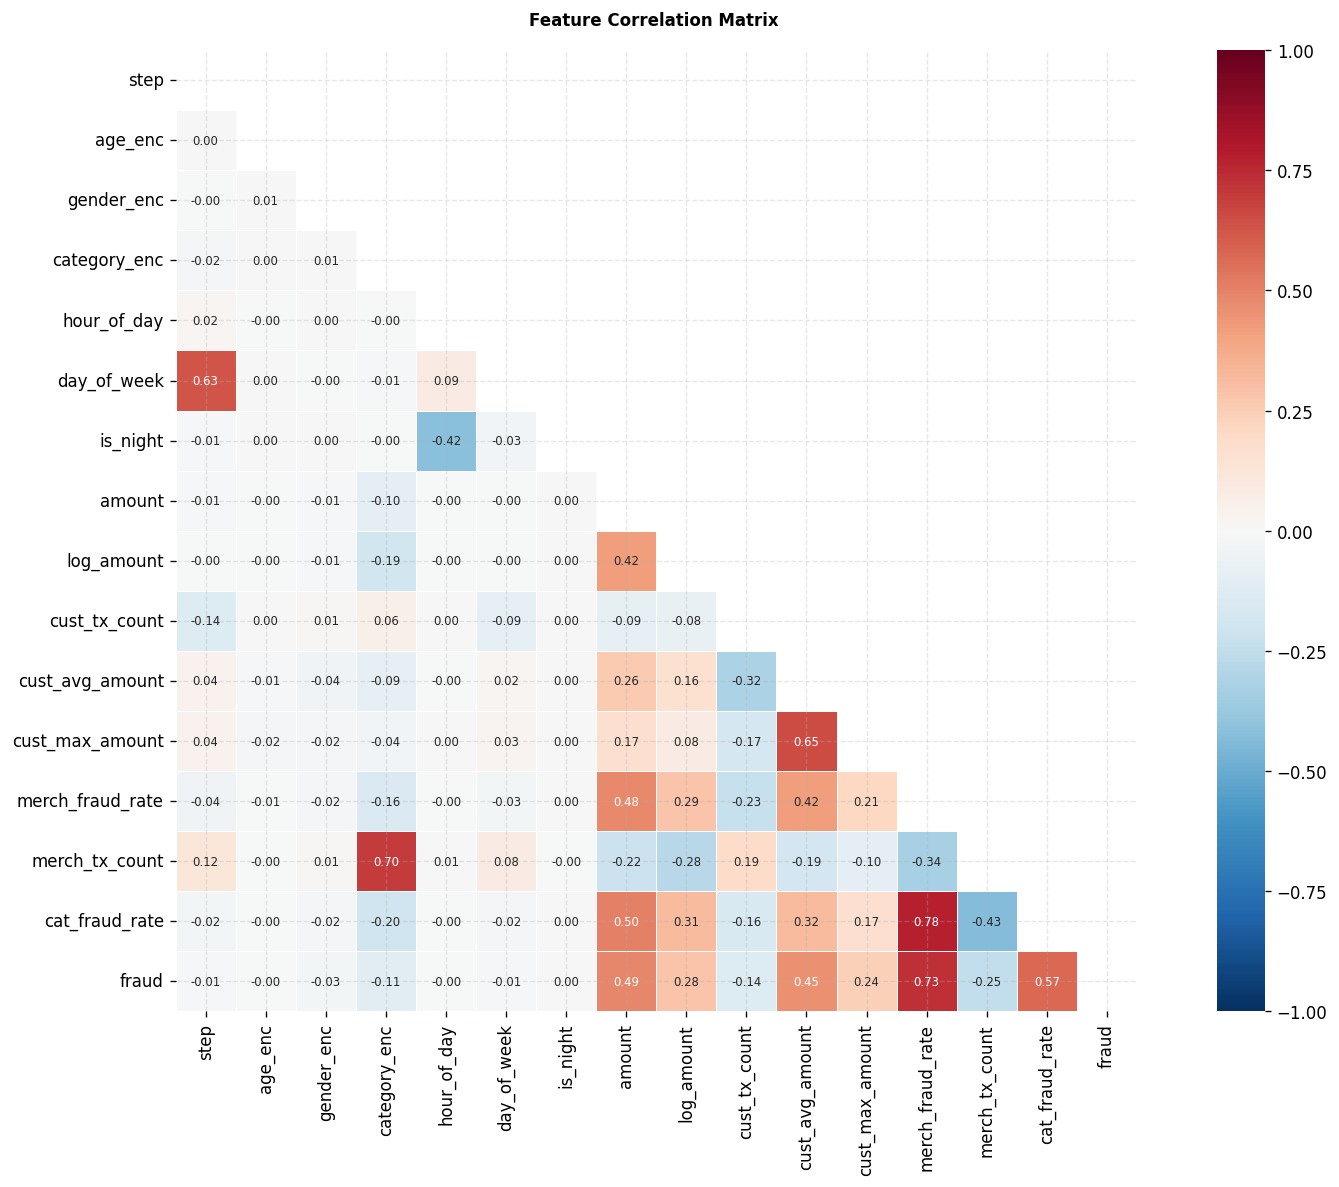

In [21]:
# Correlation heatmap 

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = pd.concat([X, y], axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  

sns.heatmap(
    corr_matrix,
    mask=mask, ax=ax,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.5, square=True,
)
ax.set_title("Feature Correlation Matrix ", fontsize=10, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


In [22]:
# Stratified train/test split summary
# The actual split was already created in Section 4 when leakage-safe aggregate
# features were built. We do NOT split again here.

print(f"Train set : {X_train.shape[0]:,} rows  |  fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test set  : {X_test.shape[0]:,} rows  |  fraud rate: {y_test.mean()*100:.2f}%")
print(f"\nTrain fraud count : {y_train.sum():,}")
print(f"Test  fraud count : {y_test.sum():,}")
print("\n Using the existing leakage-safe train/test split.")


Train set : 475,714 rows  |  fraud rate: 1.21%
Test set  : 118,929 rows  |  fraud rate: 1.21%

Train fraud count : 5,760
Test  fraud count : 1,440

 Using the existing leakage-safe train/test split.


In [23]:
# Resampling — SMOTE-NC 
# SMOTE-NC is applied ONLY to the training set.
# The test set remains untouched.

from imblearn.over_sampling import SMOTENC

print("Before SMOTE-NC:")
print(f"  Fraud     : {y_train.sum():,}  ({y_train.mean()*100:.2f}%)")
print(f"  Legitimate: {(y_train == 0).sum():,}")
print(f"  Total     : {len(y_train):,}")

# Categorical columns inside ALL_FEATURES
# These columns contain encoded categories / discrete groups.
CATEGORICAL_COLS = [
    "age_enc",
    "gender_enc",
    "category_enc",
    "hour_of_day",
    "day_of_week",
    "is_night",
]

categorical_indices = [ALL_FEATURES.index(col) for col in CATEGORICAL_COLS]

print("\nCategorical columns used by SMOTE-NC:")
print(CATEGORICAL_COLS)

smote_nc = SMOTENC(
    categorical_features=categorical_indices,
    sampling_strategy=0.10,   # minority fraud count becomes 10% of legitimate count
    random_state=SEED,
    k_neighbors=3,
)

X_train_res, y_train_res = smote_nc.fit_resample(X_train, y_train)

# Convert back to pandas objects to preserve column names
X_train_res = pd.DataFrame(X_train_res, columns=ALL_FEATURES)
y_train_res = pd.Series(y_train_res, name="fraud")

print("\nAfter SMOTE-NC:")
print(f"  Fraud     : {y_train_res.sum():,}  ({y_train_res.mean()*100:.2f}%)")
print(f"  Legitimate: {(y_train_res == 0).sum():,}")
print(f"  Total     : {len(y_train_res):,}")
print("\n SMOTE-NC applied successfully on training data only.")


Before SMOTE-NC:
  Fraud     : 5,760  (1.21%)
  Legitimate: 469,954
  Total     : 475,714

Categorical columns used by SMOTE-NC:
['age_enc', 'gender_enc', 'category_enc', 'hour_of_day', 'day_of_week', 'is_night']

After SMOTE-NC:
  Fraud     : 46,995  (9.09%)
  Legitimate: 469,954
  Total     : 516,949

 SMOTE-NC applied successfully on training data only.


In [24]:
# Train Random Forest (primary model) 


print("Training Random Forest on resampled data...")
rf = RandomForestClassifier(
    n_estimators=100,
    # class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train_res, y_train_res)
print(" Random Forest training complete")

# Convert X_test to numpy for consistent prediction calls
X_test_np = X_test.values


Training Random Forest on resampled data...
 Random Forest training complete


In [25]:
# Train Logistic Regression (baseline) 
# Logistic Regression requires feature scaling (StandardScaler).

print("Scaling features for Logistic Regression...")
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test_np)

print("Training Logistic Regression...")
lr = LogisticRegression(
    max_iter=1000,
    # class_weight="balanced",
    random_state=SEED,
)
lr.fit(X_train_sc, y_train_res)
print(" Logistic Regression training complete")


Scaling features for Logistic Regression...
Training Logistic Regression...
 Logistic Regression training complete


In [26]:
# Predict on test set 

# Random Forest
rf_pred = rf.predict(X_test_np)
rf_prob = rf.predict_proba(X_test_np)[:, 1]   # probability of fraud

# Logistic Regression
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]

print(f"Test set predictions ready. Sample RF fraud probabilities:")
print(rf_prob[:10].round(4))

Test set predictions ready. Sample RF fraud probabilities:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [27]:
# Show probabilities for actual fraud cases (not random rows)
fraud_indices = np.where(y_test == 1)[0]
print("Fraud probabilities (actual fraud rows):")
print(rf_prob[fraud_indices[:10]].round(4))

# And legitimate ones for comparison
legit_indices = np.where(y_test == 0)[0]
print("\nLegit probabilities (actual legitimate rows):")
print(rf_prob[legit_indices[:10]].round(4))

# Better summary — distribution of probabilities
print(f"\nAmong ALL test rows:")
print(f"  Prob = 0.00  : {(rf_prob == 0).sum():,} rows")
print(f"  Prob > 0.50  : {(rf_prob > 0.5).sum():,} rows  ← model flagged as fraud")
print(f"  Prob > 0.90  : {(rf_prob > 0.9).sum():,} rows  ← high confidence fraud")

Fraud probabilities (actual fraud rows):
[0.97 0.11 0.63 1.   1.   0.98 0.97 0.72 0.21 1.  ]

Legit probabilities (actual legitimate rows):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Among ALL test rows:
  Prob = 0.00  : 113,028 rows
  Prob > 0.50  : 1,522 rows  ← model flagged as fraud
  Prob > 0.90  : 869 rows  ← high confidence fraud


In [28]:
# Random Forest — full evaluation 

rf_auc   = roc_auc_score(y_test, rf_prob)
rf_prauc = average_precision_score(y_test, rf_prob)
rf_f1    = f1_score(y_test, rf_pred)
rf_cm    = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = rf_cm.ravel()

print("=" * 60)
print("         RANDOM FOREST — EVALUATION REPORT")
print("=" * 60)
print(classification_report(y_test, rf_pred, target_names=["Legitimate", "Fraud"]))
print(f"  AUC-ROC        : {rf_auc:.4f}")
print(f"  PR-AUC         : {rf_prauc:.4f}")
print(f"  F1 (fraud)     : {rf_f1:.4f}")
print(f"\n  Confusion Matrix (business view):")
print(f"     Frauds caught (TP)          : {tp:,}")
print(f"     Frauds missed (FN)          : {fn:,}")
print(f"     False alerts on legit (FP) : {fp:,}")
print(f"     Correct approvals (TN)      : {tn:,}")
print(f"\n  Fraud catch rate (Recall)      : {tp/(tp+fn)*100:.2f}%")
print(f"  False alert rate               : {fp/(fp+tn)*100:.2f}% of legitimate txns")
print("=" * 60)

         RANDOM FOREST — EVALUATION REPORT
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    117489
       Fraud       0.82      0.86      0.84      1440

    accuracy                           1.00    118929
   macro avg       0.91      0.93      0.92    118929
weighted avg       1.00      1.00      1.00    118929

  AUC-ROC        : 0.9952
  PR-AUC         : 0.9137
  F1 (fraud)     : 0.8393

  Confusion Matrix (business view):
     Frauds caught (TP)          : 1,243
     Frauds missed (FN)          : 197
     False alerts on legit (FP) : 279
     Correct approvals (TN)      : 117,210

  Fraud catch rate (Recall)      : 86.32%
  False alert rate               : 0.24% of legitimate txns


In [29]:
# Logistic Regression — evaluation 

lr_auc   = roc_auc_score(y_test, lr_prob)
lr_prauc = average_precision_score(y_test, lr_prob)
lr_f1    = f1_score(y_test, lr_pred)

print("=" * 60)
print("      LOGISTIC REGRESSION — EVALUATION REPORT")
print("=" * 60)
print(classification_report(y_test, lr_pred, target_names=["Legitimate", "Fraud"]))
print(f"  AUC-ROC    : {lr_auc:.4f}")
print(f"  PR-AUC     : {lr_prauc:.4f}")
print(f"  F1 (fraud) : {lr_f1:.4f}")
print("=" * 60)

      LOGISTIC REGRESSION — EVALUATION REPORT
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    117489
       Fraud       0.68      0.89      0.77      1440

    accuracy                           0.99    118929
   macro avg       0.84      0.94      0.88    118929
weighted avg       0.99      0.99      0.99    118929

  AUC-ROC    : 0.9970
  PR-AUC     : 0.8768
  F1 (fraud) : 0.7670


In [30]:
# Model comparison table 

comparison = pd.DataFrame({
    "AUC-ROC":  {"Random Forest": rf_auc,   "Logistic Regression": lr_auc},
    "PR-AUC":   {"Random Forest": rf_prauc, "Logistic Regression": lr_prauc},
    "F1 Fraud": {"Random Forest": rf_f1,    "Logistic Regression": lr_f1},
}).round(4)

print("Model Comparison:")
print(comparison)
print("\n Winner: Random Forest (superior F1 and PR-AUC — preferred for fraud detection)")
print("    Logistic Regression has similar AUC-ROC but lower precision → more false alerts")

Model Comparison:
                     AUC-ROC  PR-AUC  F1 Fraud
Random Forest         0.9952  0.9137    0.8393
Logistic Regression   0.9970  0.8768    0.7670

 Winner: Random Forest (superior F1 and PR-AUC — preferred for fraud detection)
    Logistic Regression has similar AUC-ROC but lower precision → more false alerts


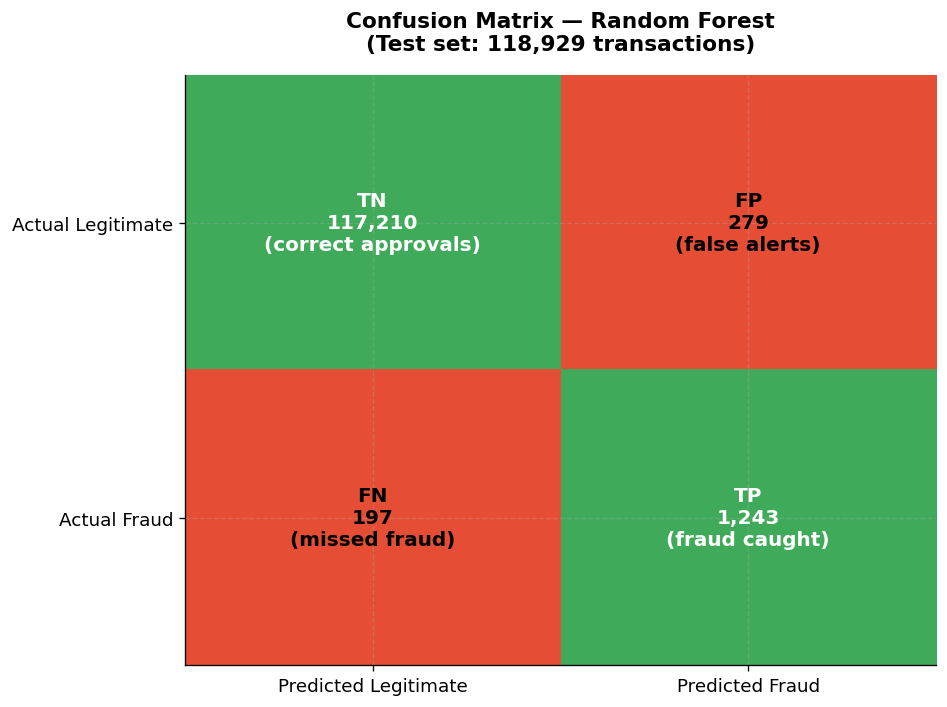

In [31]:
# Confusion matrix — visual 

labels = np.array([
    [f"TN\n{tn:,}\n(correct approvals)", f"FP\n{fp:,}\n(false alerts)"],
    [f"FN\n{fn:,}\n(missed fraud)",       f"TP\n{tp:,}\n(fraud caught)"],
])
color_grid = np.array([[0.85, 0.15], [0.15, 0.85]])  # 0=red, 1=green

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(color_grid, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i, j], ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if color_grid[i,j] > 0.5 else "black")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted Legitimate", "Predicted Fraud"], fontsize=11)
ax.set_yticklabels(["Actual Legitimate", "Actual Fraud"], fontsize=11)
ax.set_title("Confusion Matrix — Random Forest\n(Test set: 118,929 transactions)",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

In [32]:
# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

# Feature Importances
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head())

merch_fraud_rate    0.263783
merch_tx_count      0.191651
cat_fraud_rate      0.153459
log_amount          0.100819
amount              0.094645
dtype: float64


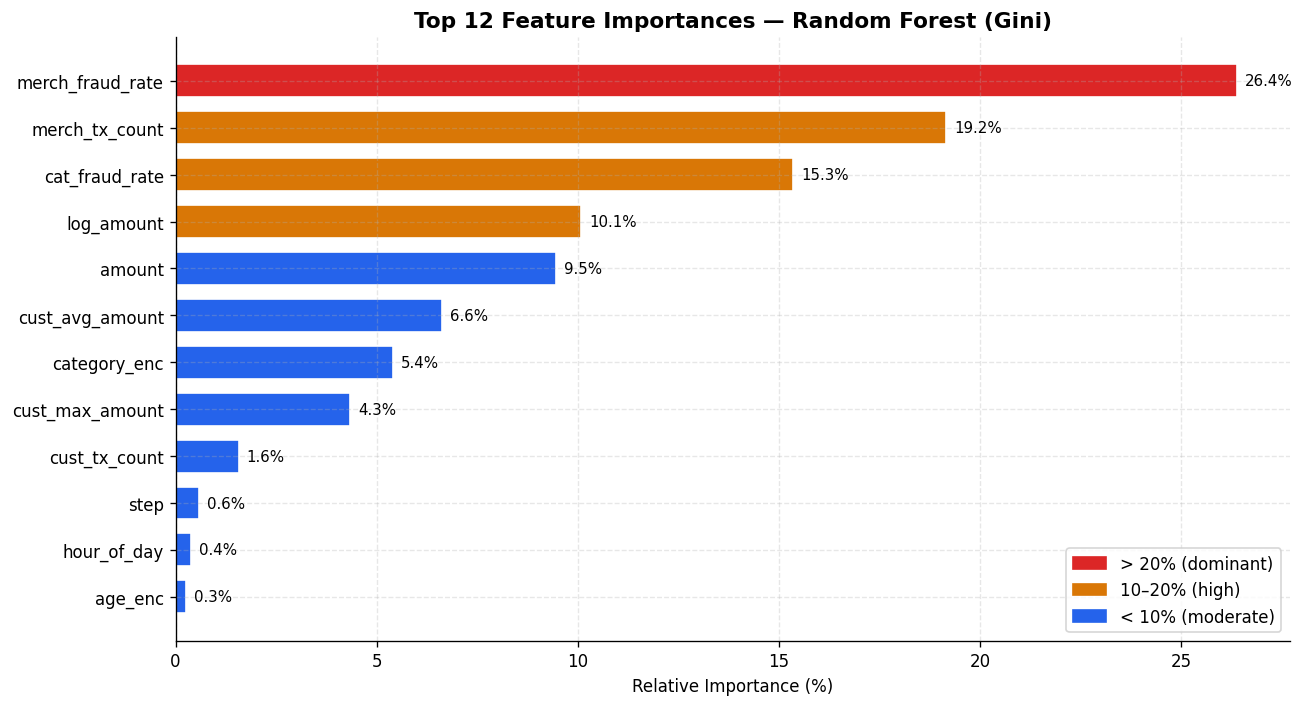


 Key Insights:
  merch_fraud_rate  (26.4%): 'WHO you transact with' is the #1 signal
  cat_fraud_rate    (15.3%): Category structural risk (leisure=95% fraud)
  amount            (9.5%): Fraud amounts avg 16.7× higher — intuitive signal
  cust_avg_amount   (6.6%): Deviation from customer baseline catches anomalies


In [33]:
# Feature importance chart 
top = importances.head(12).sort_values(ascending=True)

bar_colors = [
    PAL["fraud"] if v > 0.20 else
    PAL["amber"] if v > 0.10 else
    PAL["blue"]
    for v in top.values
]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top.index, top.values * 100, color=bar_colors,
               edgecolor="white", height=0.7)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{w:.1f}%", va="center", fontsize=9)

ax.set_xlabel("Relative Importance (%)")
ax.set_title("Top 12 Feature Importances — Random Forest (Gini)",
             fontsize=13, fontweight="bold")

legend = [
    mpatches.Patch(color=PAL["fraud"], label="> 20% (dominant)"),
    mpatches.Patch(color=PAL["amber"], label="10–20% (high)"),
    mpatches.Patch(color=PAL["blue"],  label="< 10% (moderate)"),
]
ax.legend(handles=legend)
plt.tight_layout()
plt.show()

# Interpretation
print("\n Key Insights:")
print(f"  merch_fraud_rate  ({importances['merch_fraud_rate']*100:.1f}%): 'WHO you transact with' is the #1 signal")
print(f"  cat_fraud_rate    ({importances['cat_fraud_rate']*100:.1f}%): Category structural risk (leisure=95% fraud)")
print(f"  amount            ({importances['amount']*100:.1f}%): Fraud amounts avg 16.7× higher — intuitive signal")
print(f"  cust_avg_amount   ({importances['cust_avg_amount']*100:.1f}%): Deviation from customer baseline catches anomalies")

In [34]:
# Final summary printout 
print("=" * 65)
print("  FRAUD DETECTION — PIPELINE COMPLETE")
print("=" * 65)
print(f"""
Dataset         : 594,643 transactions · 1.21% fraud rate
Primary model   : Random Forest (100 trees, SMOTE-NC, no class_weight)

Test Results    (118,929 transactions)
  AUC-ROC       : {rf_auc:.4f}
  PR-AUC        : {rf_prauc:.4f}
  F1 (fraud)    : {rf_f1:.4f}
  Precision     : {tp/(tp+fp)*100:.0f}%
  Recall        : {tp/(tp+fn)*100:.0f}%

Confusion Matrix
  Fraud caught  : {tp:,} / {tp+fn:,}  ({tp/(tp+fn)*100:.1f}%)
  Fraud missed  : {fn:,}
  False alerts  : {fp:,} ({fp/(fp+tn)*100:.2f}% of legit txns)

Top predictor   : merch_fraud_rate ({importances['merch_fraud_rate']*100:.1f}% importance)
""")
print("=" * 65)


  FRAUD DETECTION — PIPELINE COMPLETE

Dataset         : 594,643 transactions · 1.21% fraud rate
Primary model   : Random Forest (100 trees, SMOTE-NC, no class_weight)

Test Results    (118,929 transactions)
  AUC-ROC       : 0.9952
  PR-AUC        : 0.9137
  F1 (fraud)    : 0.8393
  Precision     : 82%
  Recall        : 86%

Confusion Matrix
  Fraud caught  : 1,243 / 1,440  (86.3%)
  Fraud missed  : 197
  False alerts  : 279 (0.24% of legit txns)

Top predictor   : merch_fraud_rate (26.4% importance)

